In [1]:
from sys import stdout
%matplotlib inline

In [2]:
#@title
import jax
import numpy as np

import jax.numpy as jnp
from jax import random

try:
  import flax
except ModuleNotFoundError:
  !pip install --quiet flax
  import flax

try:
  import optax
except ModuleNotFoundError:
  !pip install --quiet optax
  import optax

from flax import linen as nn
from flax.training import train_state

from tqdm import trange
from functools import partial
from matplotlib import pyplot as plt

## Data Generation

In [3]:
from typing import NamedTuple, Any

def sample_data(key, bs, up=True):
  keys = random.split(key, 3)
  if up:
    x_1 = random.randint(keys[0], minval=jnp.array([0,1]), maxval=jnp.array([2,2]), shape=(bs, 2))
  else:
    x_1 = random.randint(keys[0], minval=jnp.array([0,0]), maxval=jnp.array([2,1]), shape=(bs, 2))
  x_1 = 3*(x_1.astype(jnp.float32)-0.5)
  x_1 += 4e-1*random.normal(keys[1], shape=(bs,2))
  return x_1

ndim = 2
t_0, t_1 = 0.0, 1.0
beta_0 = 0.1
beta_1 = 20.0
log_alpha = lambda t: -0.5*t*beta_0-0.25*t**2*(beta_1-beta_0)
# log_sigma = lambda t: jnp.log(jnp.sqrt(-jnp.expm1(-t*beta_0-0.5*t**2*(beta_1-beta_0))))
log_sigma = lambda t: jnp.log(t)
dlog_alphadt = jax.grad(lambda t: log_alpha(t).sum())
dlog_sigmadt = jax.grad(lambda t: log_sigma(t).sum())
# beta_t = s_t d/dt log(s_t/alpha_t)
# beta = lambda t: jnp.exp(log_sigma(t))*(dlog_sigmadt(t) - dlog_alphadt(t))
beta = lambda t: (1 + 0.5*t*beta_0 + 0.5*t**2*(beta_1-beta_0))

def q_t(key, data, t):
  eps = random.normal(key, shape=data.shape)
  x_t = jnp.exp(log_alpha(t))*data + jnp.exp(log_sigma(t))*eps
  return eps, x_t

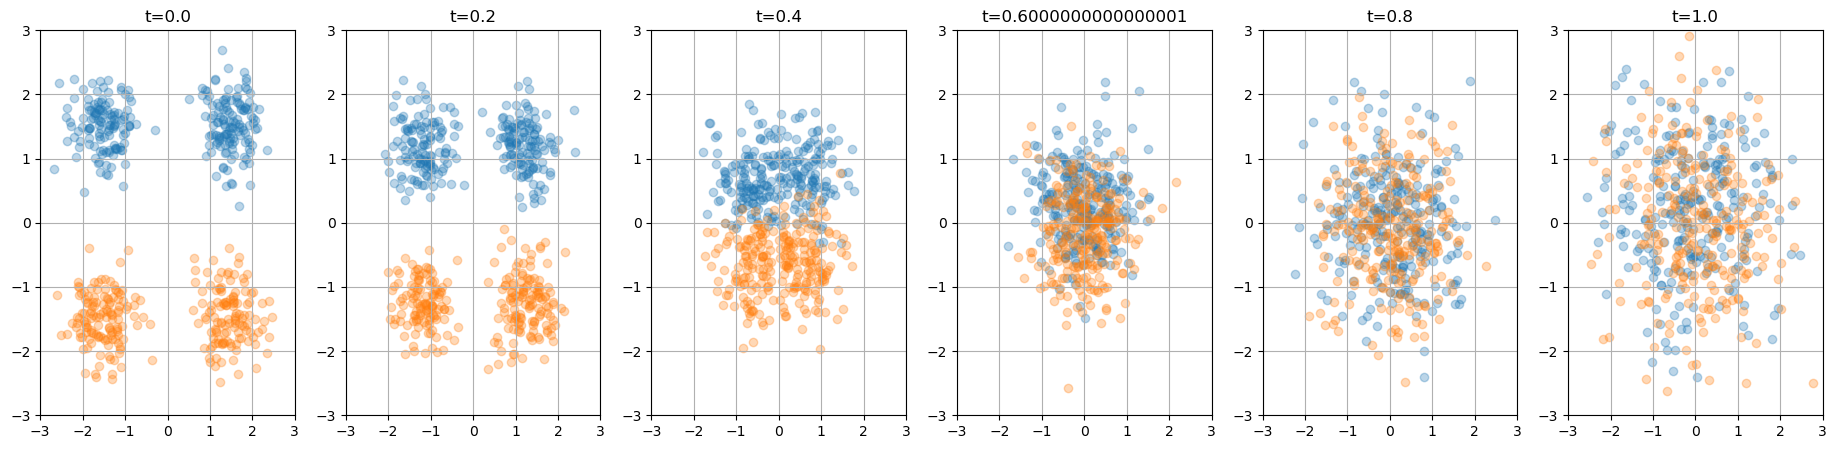

In [4]:
seed = 0
np.random.seed(seed)
key = random.PRNGKey(seed)
bs = 512
t_axis = np.linspace(0.0, 1.0, 6)

plt.figure(figsize=(23,5))
for index in range(len(t_axis)):
  plt.subplot(1,len(t_axis),index+1)
  key, *ikey = random.split(key, 5)
  _, x_t_up = q_t(ikey[1], sample_data(ikey[0], bs//2, up=True), t_axis[index])
  _, x_t_down = q_t(ikey[3], sample_data(ikey[2], bs//2, up=False), t_axis[index])
  plt.scatter(x_t_up[:,0], x_t_up[:,1], alpha=0.3)
  plt.scatter(x_t_down[:,0], x_t_down[:,1], alpha=0.3)
  plt.title(f't={t_axis[index]}')
  plt.xlim(-3,3)
  plt.ylim(-3,3)
  plt.grid()

## Define the Model

In [5]:
class MLP(nn.Module):
  num_hid : int
  num_out : int

  @nn.compact
  def __call__(self, t, x):
    h = jnp.hstack([t,x])
    h = nn.Dense(features=self.num_hid)(h)
    h = nn.swish(h)
    h = nn.Dense(features=self.num_hid)(h)
    # h = nn.swish(h)
    # h = nn.Dense(features=self.num_hid)(h)
    h = nn.swish(h)
    h = nn.Dense(features=self.num_hid)(h)
    h = nn.swish(h)
    h = nn.Dense(features=self.num_out)(h)
    return h

def train_model(key, data_generator):
  model = MLP(num_hid=512, num_out=ndim)
  key, init_key = random.split(key)
  optimizer = optax.adam(learning_rate=2e-4)
  state = train_state.TrainState.create(apply_fn=model.apply,
                                        params=model.init(init_key, np.ones([bs,1]), np.zeros([bs,ndim])),
                                        tx=optimizer)
  
  def sm_loss(state, key, params, bs):
    keys = random.split(key, )
    sdlogqdx = lambda _t, _x: state.apply_fn(params, _t, _x)
    data = data_generator(keys[0], bs)
    t = random.uniform(keys[1], [bs,1])
    eps, x_t = q_t(keys[2], data, t)
    loss = ((eps + sdlogqdx(t, x_t))**2).sum(1)
    return loss.mean()

  @partial(jax.jit, static_argnums=1)
  def train_step(state, bs, key):
    grad_fn = jax.value_and_grad(sm_loss, argnums=2)
    loss, grads = grad_fn(state, key, state.params, bs)
    state = state.apply_gradients(grads=grads)
    return state, loss
  
  num_iterations = 20_000
  key, loop_key = random.split(key)
  for iter in trange(num_iterations):
    state, _ = train_step(state, bs, random.fold_in(loop_key, iter))
  return state

In [6]:
key, ikey = random.split(key)
state_up = train_model(ikey, partial(sample_data, up=True))
key, ikey = random.split(key)
state_down = train_model(ikey, partial(sample_data, up=False))

100%|██████████| 20000/20000 [02:19<00:00, 142.89it/s]


## Analytic Models for Experiments

We want very simple Gaussian Modes to mirror propositional variables.
We can just define these mixtures of Gaussians analytically.


In [7]:
from typing import Literal
import jax
import jax.numpy as jnp
from flax import linen as nn

# ====== shared math (closed forms) ======

def _a(t):        # mean scale  a(t) = 1 - t
    return 1.0 - t

def _s2(t, sigma):  # variance schedule s^2(t) = (1-t) sigma^2 + t
    return (1.0 - t) * (sigma**2) + t

def _m(t):        # corner magnitude along each axis at time t (== 2 a(t))
    return 4.0 * _a(t)

def _mu_bar_all(x, t, sigma):
    # posterior mean of component for the "all corners" case, elementwise:
    # μ̄_j = 2 a(t) * tanh( [2 a(t) / s^2(t)] * x_j )
    at = _a(t)                   # [bs,1]
    s2t = _s2(t, sigma)          # [bs,1]
    return 2.0 * at * jnp.tanh((2.0 * at / s2t) * x)

def _mu_bar_one_side(x, t, sigma, axis: int = 0):
    at = _a(t)
    s2t = _s2(t, sigma)
    mubar = 2.0 * at * jnp.tanh((2.0 * at / s2t) * x)
    twoa = jnp.squeeze(2.0 * at, axis=-1)           # [bs]
    mubar = mubar.at[..., axis].set(twoa)           # force chosen coord to +2a(t)
    return mubar

def _score(x, t, sigma, which: Literal["all","one_side"], axis: int = 0):
    s2t = _s2(t, sigma)
    mubar = _mu_bar_all(x, t, sigma) if which == "all" else _mu_bar_one_side(x, t, sigma, axis)
    return (mubar - x) / s2t

def _loglik_one_side(x, t, sigma, axis: int = 0):
    s2t = _s2(t, sigma)
    mt  = _m(t)
    # selected (one-sided) coordinate: N(x_axis | +m, s2)
    x_axis = x[..., axis:axis+1]                    # [bs,1]
    ll_axis = -0.5 * jnp.log(2.0 * jnp.pi * s2t) - ((x_axis - mt)**2) / (2.0 * s2t)  # [bs,1]
    # remaining coordinates: symmetric mixtures
    if x.shape[-1] == 1:
        return ll_axis
    x_rest = jnp.concatenate([x[..., :axis], x[..., axis+1:]], axis=-1)  # [bs,k-1]
    xrp = -((x_rest - mt)**2) / (2.0 * s2t)
    xrm = -((x_rest + mt)**2) / (2.0 * s2t)
    per_dim = -0.5 * jnp.log(2.0 * jnp.pi * s2t) + jnp.logaddexp(xrp, xrm) - jnp.log(2.0)
    return ll_axis + jnp.sum(per_dim, axis=-1, keepdims=True)

def _loglik(x, t, sigma, which: Literal["all","one_side"], axis: int = 0):
    return _loglik_all(x, t, sigma) if which == "all" else _loglik_one_side(x, t, sigma, axis)

def _loglik_all(x, t, sigma):
    # log p_t(x) for the "all corners" case, using a stable 1D factorization.
    # per-dim: log[ 0.5 N(x|+m,s2) + 0.5 N(x|-m,s2) ]
    # = -0.5*log(2π s2) + logaddexp( -((x-m)^2)/(2s2), -((x+m)^2)/(2s2) ) - log 2
    s2t = _s2(t, sigma)                          # [bs,1]
    mt  = _m(t)                                  # [bs,1]
    xmp = - ( (x - mt)**2 ) / (2.0 * s2t)
    xmm = - ( (x + mt)**2 ) / (2.0 * s2t)
    per_dim = -0.5 * jnp.log(2.0 * jnp.pi * s2t) + jnp.logaddexp(xmp, xmm) - jnp.log(2.0)
    return jnp.sum(per_dim, axis=-1, keepdims=True)  # [bs,1]

# ====== plug-and-play modules ======

class HardcodedScore(nn.Module):
    """Drop-in replacement for MLP that outputs the score ∇_x log p_t(x)."""
    num_out: int
    sigma: float
    which: Literal["all","one_side"] = "all"
    axis: int = 0
    sign: Literal[-1, 1] = 1

    @nn.compact
    def __call__(self, t, x):
        # t: [bs,1], x: [bs,ndim]
        score = _score(x*self.sign, t, self.sigma, self.which, self.axis)*self.sign   # [bs, ndim]
        # sanity: make sure user-set num_out matches ndim
        assert score.shape[-1] == self.num_out, f"num_out={self.num_out} but x has ndim={score.shape[-1]}"
        return score
    
    @nn.compact
    def likelihood(self, t, x):
        # t: [bs,1], x: [bs,ndim]
        ll = _loglik(x*self.sign, t, self.sigma, self.which,self.axis)     # [bs,1]
        return ll

class HardcodedLogLik(nn.Module):
    """Same interface, but returns log p_t(x) in shape [bs,1]."""
    sigma: float
    which: Literal["all","one_side"] = "all"

    @nn.compact
    def __call__(self, t, x):
        ll = _loglik(x, t, self.sigma, self.which)     # [bs,1]
        assert self.num_out == 1, f"Set num_out=1 for log-likelihood; got {self.num_out}"
        return ll


## Define SAT instances and their models

In [8]:
# TODO define list of ndim/instance pairs
import itertools
def majority_dimacs(ndim: int, k: int = None):
    if k is None:
        k = ndim // 2 + 1
    return [[c + 1 for c in comb] for comb in itertools.combinations(range(ndim), k)]
    
def exactly_k_dimacs(ndim: int, k: int):
    return [[c + 1 if c in comb else -c-1 for c in range(ndim)] for comb in itertools.combinations(range(ndim), k)]
    
def xor_dimacs(ndim: int):
    """
    xor is a parity function: we proceed similar to the majority
    """
    return [i for k in range(ndim // 2 + (ndim % 2)) for i in exactly_k_dimacs(ndim,2*k+1)]
    
def exactly_one_dimacs(ndim: int):
    # CNF: (x1 ∨ ... ∨ xn) ∧ ∧_{i<j}(¬xi ∨ ¬xj)
    return [[i + 1 for i in range(ndim)]] + [[-(i + 1), -(j + 1)]
                                             for i in range(ndim)
                                             for j in range(i + 1, ndim)]

import itertools

def xor_dimacs(n):
    clauses = []
    for bits in itertools.product([0,1], repeat=n):
        if sum(bits) % 2 == 0:   # forbid even parity
            clause = [-(i+1) if bits[i] else (i+1) for i in range(n)]
            clauses.append(clause)
    return clauses


hard_instance = [
    [1, 2, 3],
    [1, -2, -3],
    [-1, 2, -3],
    [-1, -2, 3],
    [-2, -3, -4],
    [-2, 3, 4],
    [2, -3, 4],
    [2, 3, -4],
    [4, 5, 6],
    [4, -5, -6],
    [-4, 5, -6],
    [-4, -5, 6],
    [-6, -7, -8],
    [-6, 7, 8],
    [6, -7, 8],
    [6, 7, -8],
    [8, 9, 10],
    [8, -9, -10],
    [-8, 9, -10],
    [-8, -9, 10],
    [-10, -11, -12],
    [-10, 11, 12],
    [10, -11, 12],
    [10, 11, -12],
    [12, 13, 14],
    [12, -13, -14],
    [-12, 13, -14],
    [-12, -13, 14],
    [-1, -5, -9],
    [-1, 5, 9],
    [1, -5, 9],
    [1, 5, -9],
    [2, 7, 11],
    [2, -7, -11],
    [-2, 7, -11],
    [-2, -7, 11],
    # [-1],
    # [-2]
]


# TODO define checkers and reporting
# maj_instances  = [(n, majority_dimacs(n)) for n in range(2, 11)]
# xor_instances  = [(n, xor_dimacs(n)) for n in range(2, 11)]

print(exactly_one_dimacs(4))


[[1, 2, 3, 4], [-1, -2], [-1, -3], [-1, -4], [-2, -3], [-2, -4], [-3, -4]]


In [9]:
from flax.nnx import TrainState


# TODO define models and model parameters

def propositional_Gausses(ndim, sigma = .5, key = key) -> (TrainState,[TrainState]): 
    model = HardcodedScore(num_out=ndim, sigma=sigma*1.5, which="all",axis=0)
    key, init_key = random.split(key)
    optimizer = optax.adam(learning_rate=2e-4)
    state = train_state.TrainState.create(apply_fn=model.apply,
                                        params=model.init(init_key, np.ones([bs,1]), np.zeros([bs,ndim])),
                                        tx=optimizer)
    base_model = state
    dim_models = []
    for i in range(ndim):
        model = HardcodedScore(num_out=ndim, sigma=sigma, which="one_side",axis=i, sign=1)
        key, init_key = random.split(key)
        optimizer = optax.adam(learning_rate=2e-4)
        state = train_state.TrainState.create(apply_fn=model.apply,
                                              params=model.init(init_key, np.ones([bs,1]), np.zeros([bs,ndim])),
                                              tx=optimizer)
        dim_models.append(state)
    return base_model, dim_models


In [10]:
# TODO helpers
@jax.jit
def get_stoch_dll(t,dt,x,dx,sscore):
  output = ndim*dt*dlog_alphadt(t) - dt*beta(t)*(sscore**2)/jnp.exp(log_sigma(t))
  output += ((dx + dt*dlog_alphadt(t)*x)*sscore/jnp.exp(log_sigma(t)))
  return output.sum(1)

def get_dx(x_t):
    dx = -dt*(dlog_alphadt(t)*x_t - 2*beta(t)*scores)
    dx += jnp.sqrt(2*jnp.exp(log_sigma(t))*beta(t)*dt)*random.normal(ikey, shape=(bs,2))
    

# Run SAT experiment and generate CSV result file

In [11]:
from pathlib import Path
%load_ext autoreload
%autoreload 2
import sys
import os
sys.path.append(os.path.abspath(".."))
from sat.score_composer import compose_formula_with_reference, get_sscore
from sat.propositional_diffusion_models import get_ll
from sat.fuzzy_checker import analyze_sampler_sparse

# %skip

# TODO define simulation parameters

bs = 1024 #number of particles
dt = 1e-2 #delta t
t_init = 1.0 #initial t
n = int(t_init / dt) #number timesteps

lamb = 10 #lambda
ndim = 5
sigma = .5

out = ""#Path("sat_results_100_steps_fixed_xor.csv")
# with out as f:#out.open("a", encoding="utf-8") as f:
    # optional header on first write
    # if f.tell() == 0:
print("method;lambda;instance;d;n_points;n_corr;n_outside;n_wrong;perplexity;num_modes;max_count;frac_corr_all;frac_corr_within")#,
          #file=f)

for ndim in [14]: #[2,5,10,1,3,4,6,7,8,9]:
    for name,instance in [("xor",hard_instance)]: #[("majority",majority_dimacs(ndim)),
                        #   ("xor",xor_dimacs(ndim)),
                        #   ("exactly_one",exactly_one_dimacs(ndim))]:
        for method in ["dombi"]:#, "prob"]:
            for lamb in [10]: #[0.5,1,5,10,100]:
                if method == "prob" and not lamb == 1:
                    continue
                t = t_init * jnp.ones((bs, 1))
                key, ikey = random.split(key, num=2)
                # particle traces over time
                
                x_gen = jnp.zeros((bs, n + 1, ndim))
                ll_gen = jnp.zeros((bs, n + 1, 1))
                ll_gen_base = jnp.zeros((bs, n + 1, ndim))
                all_kappas_gen = jnp.zeros((bs, n + 1, ndim))
                ll_gen_clause = jnp.zeros((bs, n + 1, len(instance)))
                w_gen_base = jnp.zeros((bs, n + 1, ndim))
                x_gen = x_gen.at[:, 0, :].set(random.normal(ikey, shape=(bs, ndim)))
                
                base, dim_models = propositional_Gausses(ndim, sigma = sigma)
                dead_components = False# jnp.ones((1024,14))
                for index in range(n):
                    x_t = x_gen[:, index, :]
                    key, ikey = random.split(key, num=2)
                    (scores, lls), base_lls, clause_lls, full_k = \
                    compose_formula_with_reference(dim_models, t, x_t, instance, base, ell=lamb, method=method, gamma=1)
                    # dead_components = jnp.logical_or((full_k < 10**-2)[:,0:3],dead_components)
                    dead_components = jnp.logical_or(full_k < 10**-2, False)
                    print(dead_components)
                    # (scores, lls), base_lls, _, full_k = \
                    # compose_formula_with_reference(dim_models, t, x_t, [[1],[2],[3]], base, ell=lamb, method=method, gamma=1)
                    # (scores, lls), _, _, _ = \
                    # compose_formula_with_reference(dim_models, t, x_t, [[1],[2],[3]], base, ell=lamb, method=method, gamma=1)
                    
                    # * dead_components[0]
                    # print((get_sscore(dim_models[0], t, x_t)*dead_components[:, 0:1]).shape)
                    # x_t = x_t.at[:,0:2].set(x_t[:,0:2]+ 0.1* dead_components) 
                    # scores += (get_sscore(dim_models[0], t, x_t)*dead_components[:, 0:1]+\
                    #          get_sscore(dim_models[1], t, x_t)*dead_components[:, 1:2]+\
                    #          get_sscore(dim_models[2], t, x_t)*dead_components[:, 2:3]+\
                    #          get_sscore(dim_models[4], t, x_t)*dead_components[:, 4:5]+\
                    #          get_sscore(dim_models[6], t, x_t)*dead_components[:, 6:7]+\
                    #          get_sscore(dim_models[7], t, x_t)*dead_components[:, 7:8]+\
                    #          get_sscore(dim_models[10], t, x_t)*dead_components[:, 10:11]+\
                    #          get_sscore(dim_models[11], t, x_t)*dead_components[:, 11:12]+\
                    #          get_sscore(dim_models[12], t, x_t)*dead_components[:, 12:13]+\
                    #          get_sscore(dim_models[13], t, x_t)*dead_components[:, 13:14]
                    # )
                    
                    # scores*0 + 1/3*(get_sscore(dim_models[0], t, x_t)* dead_components[:, 0].squeeze()[:,None]+
                                    #    get_sscore(dim_models[1], t, x_t)* dead_components[:, 1].squeeze()[:,None]+
                                    #    get_sscore(dim_models[2], t, x_t)* dead_components[:, 2].squeeze()[:,None] )
                    # for particle in range(bs):
                        # if dead_components[particle].any():
                            # scores = scores.at[particle,:].set(scores[particle,:]+get_sscore(dim_models[1], t, x_t)[particle,:])
                    


                    dx = -dt * (dlog_alphadt(t) * x_t - 2 * beta(t) * scores)
                    dx += jnp.sqrt(2 * jnp.exp(log_sigma(t)) * beta(t) * dt) * random.normal(ikey, shape=(bs, ndim))
                    x_gen = x_gen.at[:, index + 1, :].set(x_t + dx)
                    ll_gen = ll_gen.at[:, index+1].set(lls)
                    ll_gen_base = ll_gen_base.at[:, index+1,:].set(jnp.stack(base_lls).squeeze().T)
                    ll_gen_clause = ll_gen_clause.at[:, index+1,:].set(jnp.stack(clause_lls).squeeze().T)
                    all_kappas_gen = all_kappas_gen.at[:,index+1,:].set(full_k)
                    
                    t -= dt

            
                x = analyze_sampler_sparse(x_gen[:, -1, :],  instance, 2, .75, metric="linf")
                anycorr = x.correct_modes_uniformity
                print(method,
                      lamb,
                      name,
                      x.d,
                      x.n_points,
                      x.correct_modes_uniformity.n if anycorr else 0,
                      x.n_points-x.n_within_sigma,
                      x.n_within_sigma-x.correct_modes_uniformity.n if anycorr else 0,
                      x.correct_modes_uniformity.perplexity if anycorr else 0,
                      x.correct_modes_uniformity.K if anycorr else 0,
                      max(x.correct_modes_uniformity.counts) if anycorr else 0,
                      x.correct_modes_uniformity.n/x.n_points if anycorr else 0,
                      x.correct_modes_uniformity.n/x.n_within_sigma if anycorr else 0, sep=";")#,#file=f,flush=True)

d=4, N=1000, metric=l2, σ=0.5, float32=True
Within σ: 1000 (1.000)
Occupied bins: 4 (collisions: 996)
Uniformity over OCCUPIED bins:
  expected per bin: 250.000 (K_occ=4)
  χ²=0.000, p=1
  TV=0.0000, L∞=0.0000, H=2.000 bits (100.0% of max), perplexity=4.00
Uniformity over OCCUPIED & CORRECT bins (K=3):
  χ²=0.000, p=1
  TV=0.0000, L∞=0.0000, H=1.585 bits, perplexity=3.00
method;lambda;instance;d;n_points;n_corr;n_outside;n_wrong;perplexity;num_modes;max_count;frac_corr_all;frac_corr_within
[[False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]]
[[False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False .

0.02734375
-13.656048
-23.907946


(Array([ 23,  66,  94, 109, 119, 142, 145, 177, 206, 244, 284, 288, 358,
        426, 450, 569, 625, 652, 719, 746, 767, 775, 816, 853, 864, 878,
        996, 997], dtype=int32),)

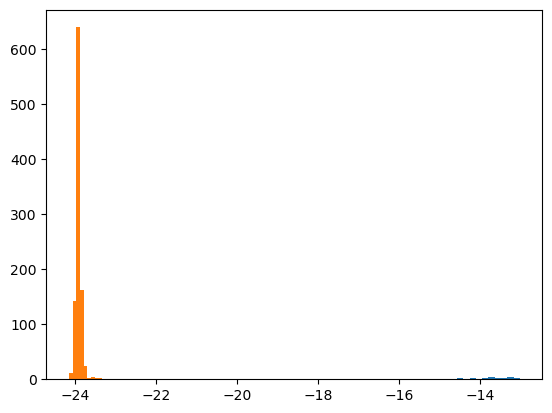

In [12]:
import matplotlib.pyplot as plt
# print((ll_gen[:,-1]>-1300).squeeze())

# def sats_instance(x: jnp.array, instance: list[list[int]]):
#     for clause in instance:
#         clause_vec = jnp.array[clause_vec]
#         vars = abs(clause_vec)-1
#         signs = clause_vec > 0


#         clause_sat = False
#         for lit in clause:
#             litt, sgn = abs(lit), lit > 0
#             if x[litt-1] > 0 == sgn:
#                 clause_sat = True
#                 break
#         if clause_sat: 
#             continue
#         return False
#     return True


def sats_instance(x, instance):
    x_true = x > 0
    def clause_ok(c):
        c = jnp.asarray(c)
        idx, sgn = jnp.abs(c) - 1, c > 0
        return jnp.any(x_true[..., idx] == sgn, axis=-1)
    return jnp.all(jnp.stack([clause_ok(c) for c in instance], axis=-1), axis=-1)


y = sats_instance(x_gen[:,-1,:],hard_instance).squeeze()
llls = ll_gen[:,-1].squeeze()
print(jnp.sum(y)/1024) #correct number


print(jnp.mean(llls[y]))
print(jnp.mean(llls[~y]))
plt.hist(llls[y])
plt.hist(llls[~y])


jnp.where(y)


In [13]:
# plt.plot(all_kappas_gen[64,:,:])
print((x_gen[:,-1] < 1.5).sum(axis=0))
x_gen[:,-1].mean(axis=0)

[520 444 530 496 479 540 517 516 513 531 509 542 535 505]


Array([0.13765384, 0.5532229 , 0.11579861, 0.27872473, 0.32746777,
       0.05649163, 0.11644142, 0.17338271, 0.22889434, 0.10808562,
       0.17084058, 0.02258494, 0.10100632, 0.2558442 ], dtype=float32)

[-51.340637 -56.9336   -23.671312 -55.019173 -23.675251 -51.827248
 -23.67132  -23.67131  -23.671312 -23.67131  -53.166378 -23.671312
 -51.565193 -59.23909 ]
[-20.820745 -19.481806 -18.174507 -18.174507 -19.474293 -19.481806
 -20.71568  -19.736866 -21.459734 -17.22567  -19.733469 -17.22567
 -19.554243 -20.072866 -20.917253 -19.554798 -19.888353 -20.498983
 -19.554802 -19.551296 -17.51638  -20.005249 -17.51638  -19.888355
 -19.930607 -19.501637 -19.501566 -21.466578 -17.225662 -18.174507
 -17.22567  -20.498985 -20.618744 -17.51638  -17.51638  -19.481806]


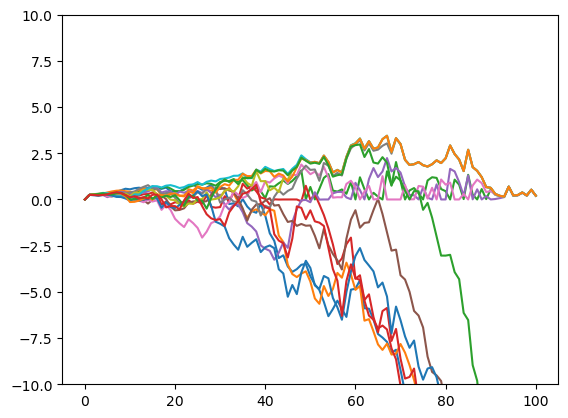

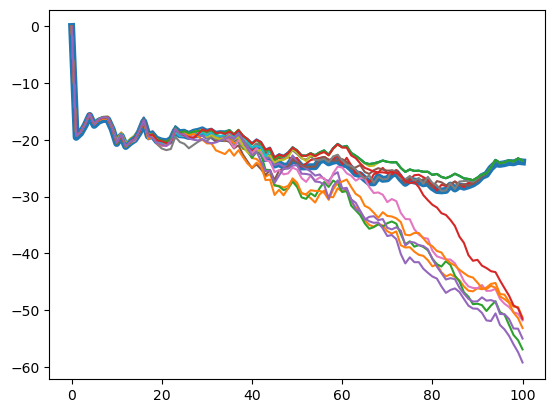

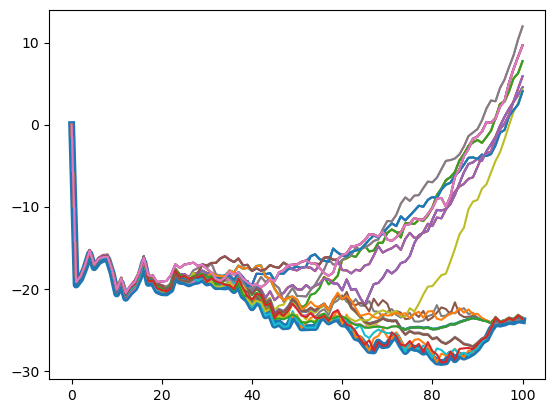

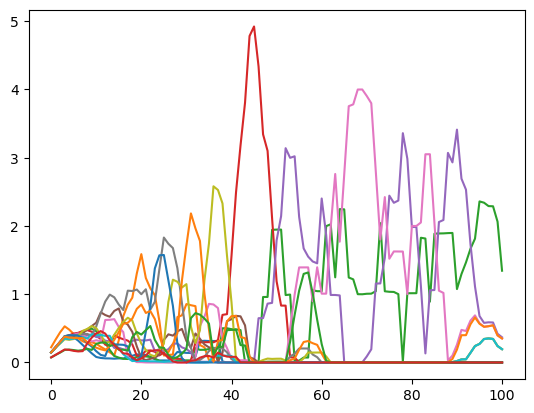

In [14]:
key = jax.random.PRNGKey(0)

particle_id = 9

# draw N(0, 1) noise with the shape you need
noise = jax.random.normal(key, shape=ll_gen_base[1].shape)   # 1D
# scale it for gentle jitter, e.g. sigma = 0.02
jitter = 0.0 * noise
# -ll_gen_base[10]
ax = plt.axes()
ax.plot(ll_gen_base[particle_id]-ll_gen[particle_id])
ax.set_ylim(-10,10)

plt.figure()
plt.plot(ll_gen[particle_id], linewidth =5)
plt.plot(ll_gen_base[particle_id])



plt.figure()
plt.plot(ll_gen[particle_id], linewidth =5)
plt.plot(ll_gen_clause[particle_id])

from jax.scipy.signal import convolve
kernel = jnp.ones((5, 1))

plt.figure()
plt.plot(convolve(all_kappas_gen[particle_id],kernel,mode='same'))


print(ll_gen_base[particle_id,-1])
print(ll_gen_clause[particle_id,-60])


## Experiment Visualisation

### Simulation

In [15]:
bs = 128 #number of particles
dt = 1e-2 #delta t
t_init = 1.0 #initial t
n = int(t_init / dt) #number timesteps

lamb = 10 #lambda
ndim = 2
sigma = .5

instance = majority_dimacs(ndim)
points = {}
for name, instance in [("majority",majority_dimacs(ndim)),
                      ("one",exactly_one_dimacs(ndim)),
                      ("xor",xor_dimacs(ndim))]:
    for method in ["dombi", "prob"]:
        t = t_init * jnp.ones((bs, 1))
        key, ikey = random.split(key, num=2)
        # particle traces over time
        
        x_gen = jnp.zeros((bs, n + 1, ndim))
        ll_gen = jnp.zeros((bs, n + 1, ndim + 1))
        x_gen = x_gen.at[:, 0, :].set(random.normal(ikey, shape=(bs, ndim)))
        
        base, dim_models = propositional_Gausses(ndim, sigma = sigma)
        
        for index in range(n):
            x_t = x_gen[:, index, :]
            key, ikey = random.split(key, num=2)
            scores, _ = compose_formula_with_reference(dim_models, t, x_t, instance, base, ell=lamb, method=method)
            
            dx = -dt * (dlog_alphadt(t) * x_t - 2 * beta(t) * scores)
            dx += jnp.sqrt(2 * jnp.exp(log_sigma(t)) * beta(t) * dt) * random.normal(ikey, shape=(bs, ndim))
            x_gen = x_gen.at[:, index + 1, :].set(x_t + dx)
            
            t -= dt
        points[name,method] = x_gen[:, index+1, :]
                        

ValueError: too many values to unpack (expected 2)

### Plotting

In [ ]:
from matplotlib import patches

plt.figure(figsize=(6, 3))

plt.subplot(1,2,1)
plt.grid()
plt.scatter(x_gen[:,0,0], x_gen[:,0,1], label='initial', alpha=.3, color="green")
plt.scatter(points["majority","dombi"][:,0], points["majority","dombi"][:,1], label='Dombi', alpha=.3, color="#0090D4")
plt.scatter(points["majority","prob"][:,0], points["majority","prob"][:,1], label='Product', alpha=.3, color="red")
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.title("$P_1 \\vee P_2$")
plt.legend()
rect = patches.Rectangle((2-0.75, 2-0.75), 1.5, 1.5,
                         linewidth=2, edgecolor='black', facecolor='none')
plt.gca().add_patch(rect)
rect = patches.Rectangle((2-0.75, -2-0.75), 1.5, 1.5,
                         linewidth=2, edgecolor='black', facecolor='none')
plt.gca().add_patch(rect)
rect = patches.Rectangle((-2-0.75, 2-0.75), 1.5, 1.5,
                         linewidth=2, edgecolor='black', facecolor='none')
plt.gca().add_patch(rect)


plt.subplot(1,2,2)
plt.grid()
plt.scatter(x_gen[:,0,0], x_gen[:,0,1], label='initial', alpha=.3, color="green")
plt.scatter(points["xor","dombi"][:,0], points["xor","dombi"][:,1], label='Dombi', alpha=.3, color="#0090D4")
plt.scatter(points["xor","prob"][:,0], points["xor","prob"][:,1], label='Product', alpha=.3, color="red")
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.legend()
plt.title("$P_1 \\text{ XOR } P_2$")

rect = patches.Rectangle((2-0.75, -2-0.75), 1.5, 1.5,
                         linewidth=2, edgecolor='black', facecolor='none')
plt.gca().add_patch(rect)
rect = patches.Rectangle((-2-0.75, 2-0.75), 1.5, 1.5,
                         linewidth=2, edgecolor='black', facecolor='none')
plt.gca().add_patch(rect)

# plt.savefig("R2_formulas.pdf", bbox_inches='tight', pad_inches=0)
plt.show()
print(xor_dimacs(2))



## Render Table

In [ ]:
import csv
from collections import defaultdict

# read CSV
rows = []
with open("sat_results_combined.csv") as f:
    reader = csv.DictReader(f, delimiter=";")
    for row in reader:
        row["d"] = int(row["d"])
        row["n_points"] = int(row["n_points"])
        row["n_outside"] = int(row["n_outside"])
        row["frac_corr_within"] = float(row["frac_corr_within"])
        row["perplexity"] = float(row["perplexity"])
        row["method"] = row["method"].lower()
        rows.append(row)

# target setup
dims = [2, 5, 10]
methods = {"prob": "Prod", "dombi": "Dombi"}
formulas = [("$\\text{Maj}_k$","majority"), ("$\\text{XOR}_k$","xor"), ("$\\text{OneHot}_k$","exactly_one")]

# collect data: {formula: {method: {d: (corr_within, one_minus_outside, perplexity)}}}
table_data = defaultdict(lambda: defaultdict(dict))
for r in rows:
    if r["d"] not in dims:
        continue
    if r["method"] == "dombi" and float(r["lambda"]) != 100:
        continue
    if r["method"] == "prob" and float(r["lambda"]) != 1:
        continue

    corr_within = r["frac_corr_within"]
    one_minus_outside = 1 - (r["n_outside"] / r["n_points"])
    perplexity = r["perplexity"]

    table_data[r["instance"]][methods[r["method"]]][r["d"]] = (
        corr_within, one_minus_outside, perplexity
    )

# --- Generate LaTeX ---
print("\\begin{table*}[h]")
print("\\centering")
print("\\begin{tabular}{cc"+"".join(["ccc" for _ in dims]) + "}")
print("\\toprule")

# header row
print("&&" + "&".join([f"\\multicolumn{{3}}{{c}}{{Dim {d}}}" for d in dims]) + " \\\\")
print("" + "".join([f"\\cmidrule(l{{3pt}}r{{3pt}}){{{col*3+3}-{col*3+5}}}" for col,_ in enumerate(dims)]) + " \\\\")
print("Formula&Method&" + "&".join(["SAT&Surv&P" for _ in dims]) + " \\\\")
print("\\midrule")

# body
for name, formula in formulas:
    methods_here = list(table_data[formula].keys())
    if not methods_here:
        continue
    print(f"\\multirow{{{len(methods_here)}}}{{*}}{{{name}}}", end=" ")
    for index, method in enumerate(methods_here):
        if index > 0:
            print(" &", end=" ")
        else:
            print("&", end=" ")
        print(method, end=" ")
        for d in dims:
            vals = table_data[formula][method].get(d, ("-", "-", "-"))
            if isinstance(vals[0], float):
                print(f"&{vals[0]:.2f}&{vals[1]:.2f}&{vals[2]:.2f}", end=" ")
            else:
                print("& - & - & -", end=" ")
        print("\\\\")
    print("\\midrule")

print("\\bottomrule")
print("\\end{tabular}")
print("\\caption{Comparison of Dombi vs Product across selected dimensions.}")
print("\\end{table*}")



# With FKC

In [ ]:
from sat.propositional_diffusion_models import get_sscore
from library.feynman_kac_correction.fkc_power_norms import fkc_power_norm, \
    fkc_referenced_cnf_composition
from library.feynman_kac_correction.fkc_by_terms import fkc_annealing_full_pde
from library.feynman_kac_corrector import resample_cat_systematic


def log_prob_std_normal(x):
    """
    Log-likelihood under isotropic N(0, I) for a batch of particles.
    x: (batch_size, ndim)
    """
    d = x.shape[-1]
    return -0.5 * (jnp.sum(x**2, axis=-1) + d * jnp.log(2 * jnp.pi))

bs = 2048 #number of particles
dt = 1e-2 #delta t
t_init = 1.0 #initial t
n = int(t_init / dt) #number timesteps
resample = True
lamb = 5 #lambda
ndim = 5
sigma = .5

# def majority_dimacs(d):
#     return [[1,2]]
# xor_dimacs = exactly_one_dimacs = majority_dimacs


instance = majority_dimacs(ndim)
points = {}
for ndim in [10,3,4,5,6,7,8,9,10,15]:
    for name, instance in [("one",exactly_one_dimacs(ndim)),
                           ("xor",xor_dimacs(ndim)),
                          ("majority",majority_dimacs(ndim))]:
        for method in ["dombi", "prob"]:
            t = t_init * jnp.ones((bs, 1))
            key, ikey = random.split(key, num=2)
            # particle traces over time
            # 
            x_gen = jnp.zeros((bs, n + 1, ndim))
            ll_gen = jnp.zeros((bs, n + 1))
            w_gen = jnp.zeros((bs, n + 1))
            x_gen = x_gen.at[:, 0, :].set(random.normal(ikey, shape=(bs, ndim)))
            
            base, dim_models = propositional_Gausses(ndim, sigma = sigma)
            
            for index in range(n):
                x_t = x_gen[:, index, :]
                key, ikey = random.split(key, num=2)
                big_score, big_lls = compose_formula_with_reference(dim_models, t, x_t, instance, base, ell=lamb, method=method)
                
                # model
                # TODO!!
                scores = [get_sscore(model, t, x_t) for model in dim_models]
                lls = [get_ll(model, t, x_t) for model in dim_models]
                      
                div_f = dlog_alphadt(t)*ndim # divergence of the drift field
                g = jnp.sqrt(2/jnp.exp(log_sigma(t))*beta(t)) # diffusion coefficient
                
                score, ll, weight = fkc_referenced_cnf_composition(
                    [score*g for score in scores],
                    lls,
                    get_sscore(base,t,x_t)*g,
                    get_ll(base,t,x_t),
                    # 1/jnp.exp(log_sigma(t))*g
                    div_f,
                    instance,
                    lamb
                )
                # print(big_lls - ll)
                # score*jnp.exp(log_sigma(t))/g
                # print(score*jnp.exp(log_sigma(t))/g-big_score)
    
                
                dx = -dt * (dlog_alphadt(t) * x_t - 2 * beta(t) * score/g)
                dx += jnp.sqrt(2 * jnp.exp(log_sigma(t)) * beta(t) * dt) * random.normal(ikey, shape=(bs, ndim))
    
                # print(dw.shape)
                w_gen = w_gen.at[:,index+1].set(w_gen[:,index] + dt*weight)
                # print(jnp.min(dt*weight[:,None]))
                if resample and .10 < t[0] < .3:
                    key, ikey = random.split(key, num=2)
                    new_ids = resample_cat_systematic(bs, ikey, w_gen[:,index+1])
                    x_gen = x_gen.at[:,index+1].set(x_gen[new_ids,index+1,:])
                w_gen = w_gen.at[:,index+1].set(0)
                t -= dt
            break
        break
    break
        # points[ndim, name, method] = x_gen[:, i+1, :]

## Check

In [ ]:
##TODO: WEIRD BEHAVIOR: MODE COLLAPSE *PRECISELY* AT .5
## WHY???

x = analyze_sampler_sparse(x_gen[:, index+1, :], instance, 2, 1.0, metric="linf")
    
anycorr = x.correct_modes_uniformity
print(method,
      lamb,
      name,
      x.d,
      x.n_points,
      x.correct_modes_uniformity.n if anycorr else 0,
      x.n_points-x.n_within_sigma,
      x.n_within_sigma-x.correct_modes_uniformity.n if anycorr else 0,
      "perplexity:",
      x.correct_modes_uniformity.perplexity if anycorr else 0,
      x.correct_modes_uniformity.K if anycorr else 0,
      max(x.correct_modes_uniformity.counts) if anycorr else 0,
      x.correct_modes_uniformity.n/x.n_points if anycorr else 0,
      x.correct_modes_uniformity.n/x.n_within_sigma if anycorr else 0, sep=";")

In [ ]:
print(x_gen[:,n,:].mean(axis=0))

## FKC Correctness Tests

In [ ]:
%load_ext autoreload
%autoreload 2

# import jax.numpy as jnp

def log_prob_std_normal(x):
    """
    Log-likelihood under isotropic N(0, I) for a batch of particles.
    x: (batch_size, ndim)
    """
    d = x.shape[-1]
    return -0.5 * (jnp.sum(x**2, axis=-1) + d * jnp.log(2 * jnp.pi))


from sat.propositional_diffusion_models import get_sscore
from library.feynman_kac_correction.fkc_power_norms import fkc_power_norm, fkc_power_norm_bk, \
    fkc_referenced_cnf_composition
from library.feynman_kac_correction.fkc_by_terms import fkc_annealing_full_pde,fkc_mixture_full_pde, fkc_cfg_full_pde
from library.feynman_kac_corrector import resample_cat_systematic

bs = 2048 #number of particles
dt = 1e-2 #delta t
t_init = 1.0 #initial t
n = int(t_init / dt) #number timesteps
resample = True

ndim = 2
sigma = .5
t = t_init * jnp.ones((bs, 1))
key, ikey = random.split(key, num=2)
# particle traces over time
# 
x_gen = jnp.zeros((bs, n + 1, ndim))
ll_gen = jnp.zeros((bs, n + 1, 1))
w_gen = jnp.zeros((bs, n + 1, 1))
x_gen = x_gen.at[:, 0, :].set(random.normal(ikey, shape=(bs, ndim)))
ll_gen = ll_gen.at[:,0,0].set(log_prob_std_normal(x_gen[:,0,:]))

base, dim_models = propositional_Gausses(ndim, sigma = sigma)
# instance = [[1,2]];lamb = 1 # 1 or 2, at lambda = 1 is just mixture ####WORKS
# instance = [[-2]];lamb = 1 # -2 referenced by 1 should give CFG #####WORKS
instance = [[1,-2]];lamb = 1 # 1 plus -2 ref by 1 should give Contrast with FKC ### INCONCLUSIVE??


for index in range(n):
    x_t = x_gen[:, index, :]
    key, ikey = random.split(key, num=2)
    big_score, big_lls = compose_formula_with_reference(dim_models, t, x_t, instance, base, ell=lamb, method=method)
    
    # model
    # TODO!!
    scores = [get_sscore(model, t, x_t) for model in dim_models]
    lls = [get_ll(model, t, x_t) for model in dim_models]
    # assert not jnp.isnan(lls[1]).any()
    div_f = dlog_alphadt(t)*ndim # divergence of the drift field
    g = jnp.sqrt(2/jnp.exp(log_sigma(t))*beta(t)) # diffusion coefficient
    
    score, ll, weight = fkc_referenced_cnf_composition(
        [score*g for score in scores],
        lls,
        get_sscore(base, t, x_t)*g,
        get_ll(base, t, x_t),
        # 1/jnp.exp(log_sigma(t))*g
        div_f,
        instance,
        lamb
    )
    assert not jnp.isnan(score).any(), "Score math fail"
    assert not jnp.isnan(ll).any()
    assert not jnp.isnan(weight).any()
    
    # mixture_weight = fkc_mixture_full_pde([jnp.zeros_like(score*g) for score in scores], lls)
    # print((mixture_weight-weight).sum())

    cfg_weight = fkc_cfg_full_pde([score*g for score in scores],2)
    print(cfg_weight.sum(), weight.sum(), (cfg_weight - weight).sum())

    #print(big_lls - ll)
    # score*jnp.exp(log_sigma(t))/g
    # print(score*jnp.exp(log_sigma(t))/g-big_score)

    
    dx = -dt * (dlog_alphadt(t) * x_t - 2 * beta(t) * score/g)
    dx += jnp.sqrt(2 * jnp.exp(log_sigma(t)) * beta(t) * dt) * random.normal(ikey, shape=(bs, ndim))
    x_gen = x_gen.at[:, index + 1, :].set(x_t + dx)
    # print(dw.shape)
    w_gen = w_gen.at[:,index+1,:].set(w_gen[:,index,:] + dt*weight*.35)
    # print(jnp.min(dt*weight[:,None]))
    if resample:
        key, ikey = random.split(key, num=2)
        new_ids = resample_cat_systematic(bs, ikey, w_gen[:,index+1,0])
        x_gen = x_gen.at[:,index+1,:].set(x_gen[new_ids,index+1,:])
        w_gen = w_gen.at[:,index+1,:].set(0)
    t -= dt

## Visualisation

In [ ]:
from matplotlib import patches

plt.figure(figsize=(6, 3))

plt.subplot(1,2,1)
plt.grid()
plt.scatter(x_gen[:,0,0], x_gen[:,0,1], label='initial', alpha=.3, color="green")
plt.scatter(points["majority","dombi"][:,0], points["majority","dombi"][:,1], label='Dombi', alpha=.3, color="#0090D4")
plt.scatter(points["majority","prob"][:,0], points["majority","prob"][:,1], label='Product', alpha=.3, color="red")
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.title("$P_1 \\vee P_2$")
plt.legend()
rect = patches.Rectangle((2-0.75, 2-0.75), 1.5, 1.5,
                         linewidth=2, edgecolor='black', facecolor='none')
plt.gca().add_patch(rect)
rect = patches.Rectangle((2-0.75, -2-0.75), 1.5, 1.5,
                         linewidth=2, edgecolor='black', facecolor='none')
plt.gca().add_patch(rect)
rect = patches.Rectangle((-2-0.75, 2-0.75), 1.5, 1.5,
                         linewidth=2, edgecolor='black', facecolor='none')
plt.gca().add_patch(rect)


plt.subplot(1,2,2)
plt.grid()
plt.scatter(x_gen[:,0,0], x_gen[:,0,1], label='initial', alpha=.3, color="green")
plt.scatter(points["xor","dombi"][:,0], points["xor","dombi"][:,1], label='Dombi', alpha=.3, color="#0090D4")
plt.scatter(points["xor","prob"][:,0], points["xor","prob"][:,1], label='Product', alpha=.3, color="red")
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.legend()
plt.title("$P_1 \\text{ XOR } P_2$")

rect = patches.Rectangle((2-0.75, -2-0.75), 1.5, 1.5,
                         linewidth=2, edgecolor='black', facecolor='none')
plt.gca().add_patch(rect)
rect = patches.Rectangle((-2-0.75, 2-0.75), 1.5, 1.5,
                         linewidth=2, edgecolor='black', facecolor='none')
plt.gca().add_patch(rect)

# plt.savefig("R2_formulas.pdf", bbox_inches='tight', pad_inches=0)
plt.show()
print(xor_dimacs(2))



## Random stuff

In [ ]:
print(instance)

anycorr = x.correct_modes_uniformity
# print(x_t)
print(
    x.d,
      x.n_points,
      x.correct_modes_uniformity.n if anycorr else 0,
      x.n_points-x.n_within_sigma,
      x.n_within_sigma-x.correct_modes_uniformity.n if anycorr else 0,
      x.correct_modes_uniformity.perplexity if anycorr else 0,
      x.correct_modes_uniformity.K if anycorr else 0,
      max(x.correct_modes_uniformity.counts) if anycorr else 0,
      x.correct_modes_uniformity.n/x.n_points if anycorr else 0)
# print(instance)

In [ ]:
from sat.fuzzy_checker import analyze_sampler_sparse

x = analyze_sampler_sparse(x_gen[:, -1, :], instance, 2, .75, metric="linf")
print(x)
print(
    f'\n\n\n{x.correct_modes_uniformity.n} correct and {x.all_modes_uniformity.n - x.correct_modes_uniformity.n} incorrect :(\nCorrect mode perplexity is {x.correct_modes_uniformity.perplexity}')

## Create an Analytic Model

In [ ]:
from sat.propositional_diffusion_models import HardcodedScore
from sat.parse import parse_dimacs_cnf
clauses = [
    [1, 2, 3],
    [1, -2, -3],
    [-1, 2, -3],
    [-1, -2, 3],
    [-2, -3, -4],
    [-2, 3, 4],
    [2, -3, 4],
    [2, 3, -4],
    [4, 5, 6],
    [4, -5, -6],
    [-4, 5, -6],
    [-4, -5, 6],
    [-6, -7, -8],
    [-6, 7, 8],
    [6, -7, 8],
    [6, 7, -8],
    [8, 9, 10],
    [8, -9, -10],
    [-8, 9, -10],
    [-8, -9, 10],
    [-10, -11, -12],
    [-10, 11, 12],
    [10, -11, 12],
    [10, 11, -12],
    [12, 13, 14],
    [12, -13, -14],
    [-12, 13, -14],
    [-12, -13, 14],
    [-1, -5, -9],
    [-1, 5, 9],
    [1, -5, 9],
    [1, 5, -9],
    [2, 7, 11],
    [2, -7, -11],
    [-2, 7, -11],
    [-2, -7, 11],
    [-1],
    [-2]
] # 8 models out of 2**14 ~= 16k

# ndim, instance = parse_dimacs_cnf("../sat_instances/uf20-07.cnf")
# ndim, instance = 5, [[1,-2],[-1,2],[1,-3],[-1,3],[2,-3],[-2,3],[-4,5]]
ndim, instance = 3, [[i for i in range(1,4)]]
# ndim, instance = 2, [[1,-2],[-1,2]]
# ndim, instance = 14, clauses
model = HardcodedScore(num_out=ndim, sigma=.5, which="all",axis=0)
key, init_key = random.split(key)
optimizer = optax.adam(learning_rate=2e-4)
state = train_state.TrainState.create(apply_fn=model.apply,
                                    params=model.init(init_key, np.ones([bs,1]), np.zeros([bs,ndim])),
                                    tx=optimizer)
base_model = state
dim_models = []
for index in range(ndim):
    states = {}
    for sign in [1,-1]:
        model = HardcodedScore(num_out=ndim, sigma=.5, which="one_side",axis=index, sign=sign)
        key, init_key = random.split(key)
        optimizer = optax.adam(learning_rate=2e-4)
        state = train_state.TrainState.create(apply_fn=model.apply,
                                            params=model.init(init_key, np.ones([bs,1]), np.zeros([bs,ndim])),
                                            tx=optimizer)
        states[sign] = state
    dim_models.append(states)
print(3)

## Stochastic Superposition and Dombi Composition

In [ ]:
%load_ext autoreload
%autoreload 2
from sat.score_composer import compose_formula, compose_formula_reference

bs = 1024*4

dt = 1e-2
t = 1.0
n = int(t / dt)
t = t * jnp.ones((bs, 1))
key, ikey = random.split(key, num=2)
x_gen = jnp.zeros((bs, n + 1, ndim))
x_gen = x_gen.at[:, 0, :].set(random.normal(ikey, shape=(bs, ndim)))
for index in trange(n):
  x_t = x_gen[:, index, :]
  
  key, ikey = random.split(key, num=2)
  sharpness = 100
  # print(dim_models[0][1])
  scores, _ = compose_formula_reference(dim_models, t, x_t,instance, base_model,ell=sharpness)

  dx = -dt * (dlog_alphadt(t) * x_t - 2 * beta(t) * scores)
  # print(x_t.shape,dx.shape)
  dx += jnp.sqrt(2 * jnp.exp(log_sigma(t)) * beta(t) * dt) * random.normal(ikey, shape=(bs, ndim))
  x_gen = x_gen.at[:, index + 1, :].set(x_t + dx)
  # print(jnp.mean(_ll_1,axis=0),jnp.mean(_ll_2,axis=0),jnp.mean(ll_or,axis=0),jnp.mean(ll_and,axis=0),jnp.mean(ll_all,axis=0),jnp.mean(_ll_base,axis=0))
  t += -dt

x_gen_or = jnp.copy(x_gen)
print((jnp.sign(x_gen[:, -1][:,0]) == jnp.sign(x_gen[:, -1][:,1])).sum() / 512)
plt.figure(figsize=(11.5, 10))
for index in range(len(t_axis)):
  plt.subplot(2, len(t_axis)//2, index + 1)
  key, *ikey = random.split(key, 3)
  t = t_axis[len(t_axis) - 1 - index]
  # _, x_t = q_t(ikey[1], sample_data(ikey[0], bs // 2, up=True), t)
  # plt.scatter(x_t[:, 0], x_t[:, 1], label='noise_data_up', alpha=0.3)
  # _, x_t = q_t(ikey[1], sample_data(ikey[0], bs // 2, up=False) @ jnp.array([[0, -1], [1, 0]]), t)
  # plt.scatter(x_t[:, 0], x_t[:, 1], label='noise_data_down', alpha=0.3)
  plt.scatter(x_gen[:, int(n * (t_axis[index])), 0], x_gen[:, int(n * (t_axis[index])), 1], label='gen_data', alpha=.3, color="orange")
  plt.title(f't={t}')
  plt.xlim(-6, 6)
  plt.ylim(-6, 6)
  plt.grid()
  if index == 0:
    plt.legend(fontsize=15)
  plt.savefig("actual_xor.svg", bbox_inches="tight")

In [ ]:
from sat.fuzzy_checker import analyze_sampler_sparse
x = analyze_sampler_sparse(x_gen[:,int(n * (t_axis[index])),:], instance, 2, .75, metric="linf")
print(x)
print(f'\n\n\n{x.correct_modes_uniformity.n} correct and {x.all_modes_uniformity.n- x.correct_modes_uniformity.n} incorrect :(\nCorrect mode perplexity is {x.correct_modes_uniformity.perplexity}')

# Refactor TODO List

We want to use a more modular composition logic, to simplify the whole procedure.
Maybe with nested operators.

- idea: allow arbitrary nesting, interpret min/max by *parity*
- idea: following pipeline
  - obtain all component likelihoods in a list, obtain all component scores in a list
  - replace negated models with their explicit counterpart, i.e., a list \[modelindex\]\[sign\], pass only the likelihoods to the function.
  - compute the kappa values for each component and aggregate through the junction graph, ideally a method to get the "signed and unsigned" kappas.
  - ideally a kappa for each junction node. should then basically be a list in form of the formula, but with tuples \[(kappa,\[subformula_list\])\].
- so the code should take: likelihoods (components + base) (in subroutine to be preprocessed into explicit negated likelihoods), a formula; and returns a weighted formula
- i can flatten this in two ways: signed and unsigned. the signed version i can immediately multiply with the component scores and be done. the flattened kappa i can use to see how much the model just approaches the baseline (not what i want, possible trigger for backtracking?)

THEN:
- i need to implement some active branch tracking method.
- in and nodes all children should be active, in or nodes one. i can in either way just look at the kappa contributions
- THEN i need to to implement a method to force different branches to be active, so maybe i can integrate that into the flattening code.

In [16]:
from typing import List
from jax import Array

from typing import Sequence, Tuple, TypeAlias, Union
from jaxtyping import Array, Float, Int
from typing import Literal  # for the (1, Lit) discriminator

Lit: TypeAlias = int # one dimensional of shape (N,)

# Some Types that give alternating Disjunction, Conjunction with list nesting
Formula: TypeAlias = Union[Lit, Sequence["Formula"]]
Annotated_Formula: TypeAlias = Union[
    Lit, 
    Sequence[Tuple[Float[Array, "N"], "Annotated_Formula"]]
]

# Annotated_DFormula = (1, Lit) | List[(float, Annotated_CFormula)]

def standard_negation(log_quantity: Array,reference_log_quantity: Array, gamma: float = 1) -> Array:
    return (gamma + 1) * reference_log_quantity - gamma * log_quantity



def compose_likelihoods(likelihoods: Sequence[Array], base_ll: Array, inv_temp: float, formula: Formula) -> tuple[Array, Annotated_Formula]:
    """
    Formula is assumed to be in conjunctive form if inv_temp < 0, disjunctive else.
    Nested subformulas flip the sign of inv_temp to alternate between conjunction and disjunction.
    """
    
    if isinstance(formula, Lit):
        assert formula != 0.0, "Literal indexing needs to start with 1"
        ll = likelihoods[abs(formula)-1]
        if formula < 0:
            ll = standard_negation(ll, base_ll)
        return ll, formula
    
    sub_results = [compose_likelihoods(likelihoods, base_ll, -inv_temp, sub)
                   for sub in formula]
    sub_lls, annotated_subs = zip(*sub_results)

    logits = jnp.stack([inv_temp * ll for ll in sub_lls], axis=1)
    kappas = jax.nn.softmax(logits, axis=1)
    ll = jax.nn.logsumexp(logits, axis=1) / inv_temp
    annotated: Annotated_Formula = [(kappas[:,idx],subformula) for idx, subformula in enumerate(annotated_subs)]
    return ll, annotated

lls = [jnp.ones(50)]*5
ll, kp = compose_likelihoods(lls, jnp.ones(50), -500, [[[1]], [-1], [[4, 1, -3, [5, [1, [1, 2]]]]]])
# print(kp[0][0].shape, "kappa?")
# print(kp)

def flatten_kappas(annotated: Annotated_Formula, num_lits: float) -> Float[Array, "N K"]:
    """
    Returns an array of shape (N, K), where:
      - N is the number of literals in the leaf array
      - K = num_lits + 1 (column 0 is the baseline contribution)
    """
    if isinstance(annotated, Lit):
        weight = jnp.zeros((num_lits+1))
        sgn = jnp.sign(annotated)
        if annotated < 0:
            weight = weight.at[0].set(2.)
        assert num_lits >= abs(annotated), "Index out of Bounds, increase num_lits"
        return weight.at[abs(annotated)].set(sgn)
    return jnp.stack([kappa[:,None]*flatten_kappas(sub_annotated, num_lits) for kappa, sub_annotated in annotated], axis=0).sum(axis=0)

kps = flatten_kappas(kp, 10)


In [93]:
from typing import Union, Sequence, Tuple, List, Dict
import numpy as np, matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# Lit=int
# Annotated_Formula=Union[Lit,Sequence[Tuple[np.ndarray,"Annotated_Formula"]]]

def animate_annotated_tree(formulas: List[Annotated_Formula]|Annotated_Formula, index:int, out_path:str|None=None, interval:int=75, conjunction=True):
    if not isinstance(formulas,list): formulas=[formulas]
    f0=formulas[0]; children:Dict[int,List[int]]={}; depth:Dict[int,int]={}
    def build(node,n=0,d=0):
        depth[n]=d; children[n]=[]
        if isinstance(node,int): return n+1
        k=n+1
        for _,sub in node: children[n].append(k); k=build(sub,k,d+1)
        return k
    N=build(f0); pos={}; x=0.0
    def place(n):
        nonlocal x
        if not children[n]: p=x; x+=1.0
        else: p=float(np.mean([place(c) for c in children[n]]))
        pos[n]=(p,-float(depth[n])); return p
    place(0)
    def vals_labels(weight: float, node):
        V=[]; L=[]
        if isinstance(node,int): return [weight],[f"{node}"] #: {weight:.1f}
        v=weight; V.append(v); L.append(f"{v:.2f}")
        for w,sub in node:
            v2,l2=vals_labels(w[index],sub); V+=v2; L+=l2
        return V,L
    def draw(ax,V,L, t= 0):
        ax.clear()
        for u in range(N):
            for v in children[u]:
                ax.plot([pos[u][0],pos[v][0]],[pos[u][1],pos[v][1]],linewidth=1+4*abs(V[v]), color="red" if depth[v]%2==conjunction else "green")
        xs,ys=zip(*[pos[n] for n in range(N)])
        ax.scatter(xs,ys,s=150*(1+np.clip(np.abs(V),0,2)), color =["blue" if v > .1 else "gray" for v in V])
        for n in range(N): ax.text(pos[n][0],pos[n][1]+.1,L[n],ha="center",va="bottom",fontsize=8)
        ax.set_axis_off(); ax.set_title(f"Annotated tree — i={index}, time = {t}")
    fig,ax=plt.subplots(figsize=(8,5))
    # if len(formulas)==1:
    #     V,L=vals_labels(formulas[0]); draw(ax,V,L); plt.show(); return
    def update(t): 
        V,L=vals_labels(1.0,formulas[t])
        draw(ax,V,L, t)
        return []
    anim=FuncAnimation(fig,update,frames=len(formulas),interval=interval,blit=False)
    if out_path:
        anim.save(out_path,writer=PillowWriter(fps=max(1,int(1000/interval))))
    else:
        return anim
    



In [ ]:

# ll, kp = compose_likelihoods(lls, jnp.ones_like(base_lls[0]), -5, [[[1,-2]],3]) # 3 AND (1 AND -2)
ll, kp = compose_likelihoods(lls, base_lls[0], -.5, [[[1]], [1], [[4, -1, -3, [5, [1, [1, 2]]]]]])
kps = flatten_kappas(kp, 5)
kps.max(axis=0), kps.sum(axis=1).min(), abs(kps[:,1:]).sum(axis=1).min()
kps

Array([[ 1.9224652e+00,  2.0000000e+00,  1.8970633e+00, ...,
         1.9066453e+00,  2.0000000e+00,  1.9130905e+00],
       [-4.5692503e-01, -5.0000000e-01, -4.4281292e-01, ...,
        -4.4813627e-01, -5.0000000e-01, -4.5171690e-01],
       [ 4.3075019e-04,  0.0000000e+00,  5.7187089e-04, ...,
         5.1863707e-04,  0.0000000e+00,  4.8283118e-04],
       [-4.8061630e-01, -5.0000000e-01, -4.7426581e-01, ...,
        -4.7666132e-01, -5.0000000e-01, -4.7827262e-01],
       [ 1.0768752e-02,  0.0000000e+00,  1.4296766e-02, ...,
         1.2965927e-02,  0.0000000e+00,  1.2070776e-02],
       [ 3.8767511e-03,  0.0000000e+00,  5.1468369e-03, ...,
         4.6677333e-03,  0.0000000e+00,  4.3454799e-03]], dtype=float32)

In [485]:
from pathlib import Path
from tqdm import tqdm
%load_ext autoreload
%autoreload 2
import sys
import os
sys.path.append(os.path.abspath(".."))
from sat.score_composer import compose_formula_with_reference, get_sscore, get_ll
from sat.propositional_diffusion_models import get_ll
from sat.fuzzy_checker import analyze_sampler_sparse

# %skip
def propositional_Gausses(ndim, sigma = .5, key = key) -> (TrainState,[TrainState]): 
    model = HardcodedScore(num_out=ndim, sigma=sigma*1.25, which="all",axis=0)
    key, init_key = random.split(key)
    optimizer = optax.adam(learning_rate=2e-4)
    state = train_state.TrainState.create(apply_fn=model.apply,
                                        params=model.init(init_key, np.ones([bs,1]), np.zeros([bs,ndim])),
                                        tx=optimizer)
    base_model = state
    dim_models = []
    for i in range(ndim):
        model = HardcodedScore(num_out=ndim, sigma=sigma, which="one_side",axis=i, sign=1)
        key, init_key = random.split(key)
        optimizer = optax.adam(learning_rate=2e-4)
        state = train_state.TrainState.create(apply_fn=model.apply,
                                              params=model.init(init_key, np.ones([bs,1]), np.zeros([bs,ndim])),
                                              tx=optimizer)
        dim_models.append(state)
    return base_model, dim_models

# TODO define simulation parameters

bs = 1024 #number of particles
dt = 1e-2 #delta t
t_init = 1.0 #initial t
n = int(t_init / dt) #number timesteps

lamb = 10 #lambda
ndim = 5
sigma = .25

out = ""#Path("sat_results_100_steps_fixed_xor.csv")
# with out as f:#out.open("a", encoding="utf-8") as f:
    # optional header on first write
    # if f.tell() == 0:
print("method;lambda;instance;d;n_points;n_corr;n_outside;n_wrong;perplexity;num_modes;max_count;frac_corr_all;frac_corr_within")#,
          #file=f)
treelist = []
for ndim in [7]: #[2,5,10,1,3,4,6,7,8,9]:
    for name,instance in [("xor",exactly_one_dimacs(ndim) + [[1]])]: #[("majority",majority_dimacs(ndim)),
                        #   ("xor",xor_dimacs(ndim)),
                        #   ("exactly_one",exactly_one_dimacs(ndim))]:
        for method in ["dombi"]:#, "prob"]:
            for lamb in [10]: #[0.5,1,5,10,100]:
                if method == "prob" and not lamb == 1:
                    continue
                t = t_init * jnp.ones((bs, 1))
                key, ikey = random.split(key, num=2)
                # particle traces over time
                
                x_gen = jnp.zeros((bs, n + 1, ndim))
                ll_gen = jnp.zeros((bs, n + 1, 1))
                ll_gen_base = jnp.zeros((bs, n + 1, ndim+1))
                all_kappas_gen = jnp.zeros((bs, n + 1, ndim+1))
                # ll_gen_clause = jnp.zeros((bs, n + 1, len(instance)))
                w_gen_base = jnp.zeros((bs, n + 1, ndim))
                x_gen = x_gen.at[:, 0, :].set(random.normal(ikey, shape=(bs, ndim)))
                
                base, dim_models = propositional_Gausses(ndim, sigma = sigma)
                dead_components = jnp.zeros((bs, ndim+1), dtype=bool)# jnp.ones((1024,14))
                for index in tqdm(range(n)):
                    x_t = x_gen[:, index, :]
                    key, ikey = random.split(key, num=2)
                    # (scores, lls), base_lls, clause_lls, full_k = \
                    # compose_formula_with_reference(dim_models, t, x_t, instance, base, ell=lamb, method=method, gamma=1)

                    ll = [get_ll(dim_model,t,x_t).squeeze() for dim_model in dim_models]
                    base_ll = get_ll(base,t,x_t).squeeze()
                    # if t[0] > .5:
                    lls, kappa_tree = compose_likelihoods(ll, base_ll, -lamb, instance) #leave lamb <0 for CNF!
                    kappa_tree = tree_interception(kappa_tree, .5,1)
                    full_k = flatten_kappas(kappa_tree,ndim)
                    if t[0] < .95:
                        kappa_tree = freeze_disjunctions(kappa_tree, old_kappa_tree, True, True)
                    # print("how many",(~(dead_components.any(axis=1))).sum())
                    old_kappa_tree = kappa_tree
                    
                    # print(full_k)
                    
                    treelist.append(kappa_tree)
                    # if not dead_components.any():
                    # if dead_components.any():
                    # full_k = full_k.at[dead_components.any(axis=1),1:].set(0.)
                    # full_k = full_k.at[dead_components].set(1.)
                        # print(dead_components.any(axis=1).all())
                        # dead_components_helper = dead_components.at[:,1:].set(True)
                        # full_k = full_k.at[~dead_components].set(0.)
                    # else:
                    # dead_components = jnp.logical_or(jnp.logical_and((full_k == 1.), ~dead_components.any(axis=1,keepdims=1)),dead_components)
                    # dead_components = jnp.logical_or(jnp.logical_or(full_k <= -1.99, (full_k >= .99) & (full_k <= 1.001)), dead_components)
                    # print(dead_components.sum())
                    # print(dead_components.sum())
                    # full_k=full_k.at[:,0].set(full_k[:,0]*2)
                    # full_k = full_k.at[dead_components].set(1.)
                    base_lls = (jnp.stack([base_ll]+ll,axis=1))
                    score = [get_sscore(dim_model,t,x_t).squeeze() for dim_model in dim_models]
                    base_score = get_sscore(base,t,x_t).squeeze()
                    # print(full_k.shape,base_score.shape)
                    scores = ((jnp.stack([base_score]+score,axis=2))*full_k[:,None]).sum(axis=2)
                    # print(base_score[0],[get_sscore(dim_model,t,x_t)[0] for dim_model in dim_models])
                    # print((jnp.stack([base_ll]+lls,axis=1)*[:]).shape,(jnp.stack([base_ll]+lls,axis=1)).shape,full_k[:].shape)
                    # dead_components = jnp.logical_or((full_k == 1.),jnp.logical_and(dead_components,t[0]<-.75))
                    # scores = scores.at[dead_components[:,1:]].set(1.)
                    # dead_components = jnp.logical_or(full_k < 10**-2, False)
                    # print(dead_components)

                    
                    dx = -dt * (dlog_alphadt(t) * x_t - 2 * beta(t) * scores)
                    # dx = dx.at[dead_components[:,1:]].set(jnp.clip(dx[dead_components[:,1:]],max=0))
                    dx += jnp.sqrt(2 * jnp.exp(log_sigma(t)) * beta(t) * dt) * random.normal(ikey, shape=(bs, ndim))
                    x_gen = x_gen.at[:, index + 1, :].set(x_t + dx)
                    ll_gen = ll_gen.at[:, index+1].set(lls[:,None])
                    ll_gen_base = ll_gen_base.at[:, index+1,:].set(jnp.stack(base_lls).squeeze())
                    # ll_gen_clause = ll_gen_clause.at[:, i+1,:].set(jnp.stack(clause_lls).squeeze().T)
                    all_kappas_gen = all_kappas_gen.at[:,index+1,:].set(full_k)
                    
                    t -= dt

            
                x = analyze_sampler_sparse(x_gen[:, -1, :],  instance, 2, .75, metric="linf")
                anycorr = x.correct_modes_uniformity
                print(method,
                      lamb,
                      name,
                      x.d,
                      x.n_points,
                      x.correct_modes_uniformity.n if anycorr else 0,
                      x.n_points-x.n_within_sigma,
                      x.n_within_sigma-x.correct_modes_uniformity.n if anycorr else x.n_within_sigma,
                      x.correct_modes_uniformity.perplexity if anycorr else 0,
                      x.correct_modes_uniformity.K if anycorr else 0,
                      max(x.correct_modes_uniformity.counts) if anycorr else 0,
                      x.correct_modes_uniformity.n/x.n_points if anycorr else 0,
                      x.correct_modes_uniformity.n/x.n_within_sigma if anycorr else 0, sep=";")#,#file=f,flush=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
method;lambda;instance;d;n_points;n_corr;n_outside;n_wrong;perplexity;num_modes;max_count;frac_corr_all;frac_corr_within


100%|██████████| 100/100 [00:27<00:00,  3.58it/s]

dombi;10;xor;7;1024;83;0;941;1.0;1;83;0.0810546875;0.0810546875


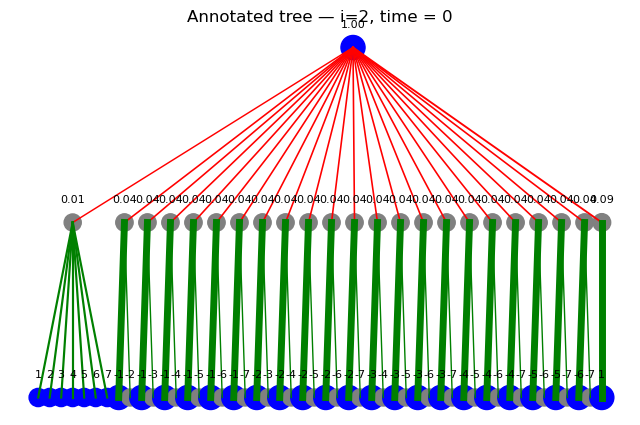

In [486]:
anim = animate_annotated_tree(treelist, index=2, interval = 100)  # no out_path
# anim
from IPython.display import HTML
HTML(anim.to_html5_video())

In [ ]:
def tree_interception(annotated: Annotated_Formula, t: Float, conjunction_sign = 1, idx = None) -> Annotated_Formula:
    """
    Assumes annotated is in conjunctive form.
    """
    # TODO: this implementation is currently only supporting CNF
    
    if t > .75 or isinstance(annotated, Lit):
        return annotated
  
    # Do the following: in conjunctions: look at the most influential branch
    #                   in disjunctions: look at all(!) non-most influential branches
    #                   in leaves: if conjunction: force kappa = 1, in disjunction, force kappa = 0
    kappas, children = zip(*annotated)
    if idx is None:
        idx = jnp.ones_like(kappas[0], dtype=bool)


    # print("num idx: ", len(idx))

    # old_shapes = [kappa.shape for kappa in kappas]
    # print(kappas,children)
    # leaf_idx = jnp.array([isinstance(child,Lit) for child in children])
    max_idx = jnp.stack(kappas, axis=1).argmax(axis=1)
    min_idx = jnp.stack(kappas, axis=1).argmin(axis=1)
    # print(max_idx)
    # iterate over batch. 
    # change child k at idx i IF max_idx[i] == k 
    # when the child is a leaf, and we should edit it, then we set kappa to 1 if it is max in conjunction_sign=1 and vice versa with 0
    # new_children = [tree_interception(child, t, -conjunction_sign, ((conjunction_sign == 1) == (max_idx == i))) for i, child in enumerate(children)]    
    # kappas = [kappa if ~leaf_idx[i] else kappa.at[idx & (max_idx == i)].set(1. if conjunction_sign == 1 else 0.) for i, kappa in enumerate(kappas)]
    # kappas = [kappa if ~leaf_idx[i] else kappa.at[idx & (max_idx != i)].set(0. if conjunction_sign == 1 else 1.) for i, kappa in enumerate(kappas)]
    # kappas[leaf_idx][idx & ~is_max_idx] = 0. if conjunction_sign == 1 else 1.
    # assert [kappa.shape for kappa in kappas] == old_shapes, "Kappas changed size"
    return [
        (kappa.at[idx].set((conjunction_sign == 1) != (i == max_idx[idx])), child) 
            if isinstance(child, Lit) else
        (kappa, tree_interception(child, t, -conjunction_sign, idx)) 
            for i, (kappa, child) in enumerate(annotated)]

# kappa.at[idx].set((conjunction_sign == 1) == (i == max_idx[idx]))
# & ((conjunction_sign == 1) == (i == max_idx))
    return zip(kappas,new_children)

    max_kappa, max_child = annotated[0][0],annotated[0][1]
    for kappa, child in annotated:
        if kappa <= max_kappa:
            continue
        max_kappa = kappa
        max_child = child
    
    # now disjunctive children

    max_sub_kappa = max_child[0][0]
    for kappa, child in max_child:
        if kappa <= max_sub_kappa:
            continue
        max_sub_kappa = kappa
    
    new_max_child = [(0., sub_annot) if kappa != max_sub_kappa else (1., sub_annot) for kappa, sub_annot in max_child]
    return [(kappa, sub_annot) if kappa != max_kappa else (kappa, new_max_child) for kappa, sub_annot in annotated]
    
def freeze_disjunctions(new_tree: Annotated_Formula, reference_tree: Annotated_Formula, conjunction: bool, idx: Array) -> Annotated_Formula:
    if isinstance(new_tree, Lit):
        return new_tree
    pair_tree = zip(new_tree, reference_tree)
    if conjunction:
        return [(kappa, freeze_disjunctions(child,ref_child, not conjunction, idx)) for ((kappa, child),(ref_kappa, ref_child)) in pair_tree]
    return [(kappa.at[idx].set(ref_kappa[idx]), freeze_disjunctions(child,ref_child, not conjunction,idx)) for ((kappa, child),(ref_kappa, ref_child)) in pair_tree]




[-2.108348  -1.9004433  1.8243592 -2.0654685 -2.0565507 -2.099211 ]
[ -3.6799634 -37.406246  -34.401108   -5.080766  -36.916332  -36.64436
 -37.547844 ]
[-20.610622 -16.874838 -20.926828 -16.874838 -16.874838 -16.874838
 -20.455835 -20.610643 -20.455173 -20.455763 -20.95659  -21.189177
 -20.821177 -20.720516 -20.69012  -21.195995 -20.721457 -17.670437
 -20.30429  -17.670437 -18.726063 -20.30429  -18.72608  -19.588997
 -20.457714 -20.633846 -19.588978 -19.588997 -17.670437 -20.87552
 -21.371346 -17.670437 -21.565727 -18.72608  -16.874838 -16.874838]
[1. 1. 1. ... 1. 1. 1.]


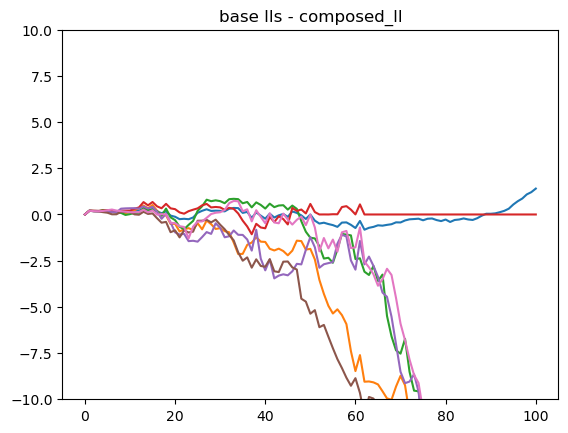

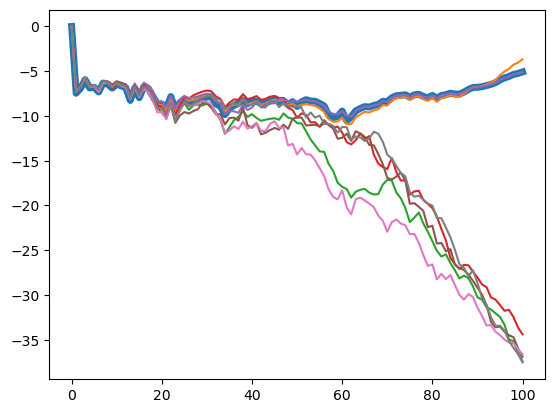

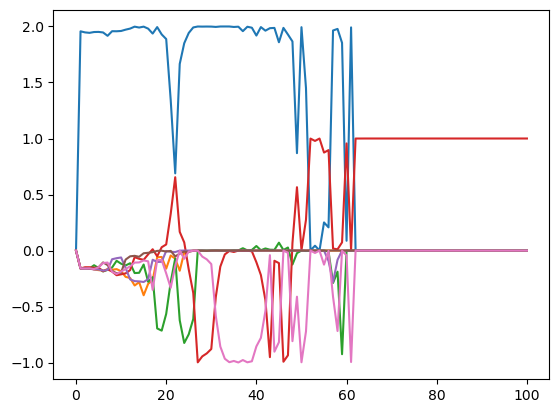

In [310]:
key = jax.random.PRNGKey(0)

particle_id = 0

# draw N(0, 1) noise with the shape you need
noise = jax.random.normal(key, shape=ll_gen_base[1].shape)   # 1D
# scale it for gentle jitter, e.g. sigma = 0.02
jitter = 0.0 * noise
# -ll_gen_base[10]
ax = plt.axes()
ax.plot(ll_gen_base[particle_id]-ll_gen[particle_id])
ax.set_ylim(-10,10)
ax.set_title("base lls - composed_ll")

plt.figure()
plt.plot(ll_gen[particle_id], linewidth =5)
plt.plot(ll_gen_base[particle_id])
# plt.set_title("base lls")


# plt.figure()
# plt.plot(ll_gen[particle_id], linewidth =5)
# plt.plot(ll_gen_clause[particle_id])
# plt.set_title()

from jax.scipy.signal import convolve
kernel = jnp.ones((1, 1))/1

plt.figure()
plt.plot(convolve(all_kappas_gen[particle_id],kernel,mode='same'))

print(x_gen[particle_id,-1])
print(ll_gen_base[particle_id,-1])
print(ll_gen_clause[particle_id,-60])
print(all_kappas_gen[:,-1,:].sum(axis=1))

0.46289062
-4.065298
-2.2195325


(Array([   2,    6,    7,   10,   11,   12,   13,   16,   17,   20,   21,
          22,   23,   26,   28,   30,   31,   32,   35,   36,   40,   43,
          50,   53,   57,   58,   68,   73,   77,   78,   79,   80,   81,
          82,   83,   84,   85,   86,   88,   89,   91,   93,   94,   96,
          97,   98,  100,  102,  103,  105,  110,  112,  115,  117,  118,
         119,  120,  121,  122,  123,  124,  125,  130,  134,  135,  136,
         137,  138,  139,  140,  141,  142,  145,  146,  149,  151,  152,
         153,  154,  155,  156,  158,  160,  161,  164,  165,  166,  167,
         169,  170,  171,  176,  177,  178,  179,  182,  183,  190,  192,
         194,  196,  197,  200,  201,  202,  204,  206,  207,  208,  209,
         210,  211,  212,  214,  219,  220,  225,  227,  228,  229,  231,
         233,  236,  239,  243,  244,  246,  247,  248,  251,  253,  254,
         255,  257,  258,  259,  260,  261,  262,  263,  264,  265,  267,
         269,  270,  273,  275,  276, 

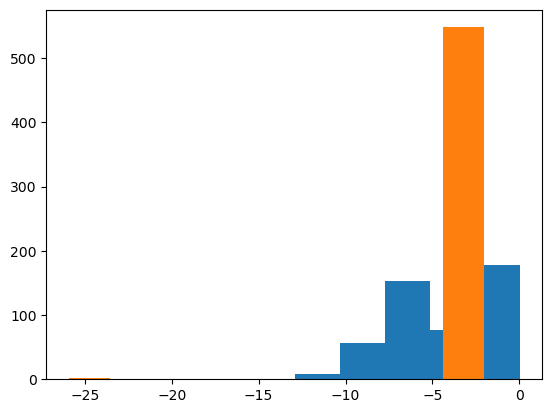

In [479]:
def sats_instance(x, instance):
    x_true = x > 0
    def clause_ok(c):
        c = jnp.asarray(c)
        idx, sgn = jnp.abs(c) - 1, c > 0
        return jnp.any(x_true[..., idx] == sgn, axis=-1)
    return jnp.all(jnp.stack([clause_ok(c) for c in instance], axis=-1), axis=-1)


y = sats_instance(x_gen[:,-1,:],instance).squeeze()
llls = ll_gen[:,-1].squeeze()
print(jnp.sum(y)/1024) #correct number


print(jnp.mean(llls[y]))
print(jnp.mean(llls[~y]))
plt.hist(llls[y])
plt.hist(llls[~y])


jnp.where(~y)


KeyError: ('majority', 'dombi')

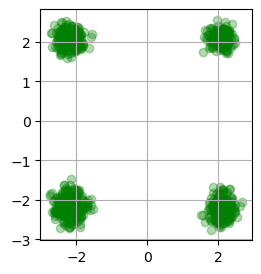

In [ ]:
from matplotlib import patches

plt.figure(figsize=(6, 3))

plt.subplot(1,2,1)
plt.grid()
plt.scatter(x_gen[:,-1,0], x_gen[:,-1,1], label='initial', alpha=.3, color="green")
plt.scatter(points["majority","dombi"][:,0], points["majority","dombi"][:,1], label='Dombi', alpha=.3, color="#0090D4")
plt.scatter(points["majority","prob"][:,0], points["majority","prob"][:,1], label='Product', alpha=.3, color="red")
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.title("$P_1 \\vee P_2$")
plt.legend()
rect = patches.Rectangle((2-0.75, 2-0.75), 1.5, 1.5,
                         linewidth=2, edgecolor='black', facecolor='none')
plt.gca().add_patch(rect)
rect = patches.Rectangle((2-0.75, -2-0.75), 1.5, 1.5,
                         linewidth=2, edgecolor='black', facecolor='none')
plt.gca().add_patch(rect)
rect = patches.Rectangle((-2-0.75, 2-0.75), 1.5, 1.5,
                         linewidth=2, edgecolor='black', facecolor='none')
plt.gca().add_patch(rect)


plt.subplot(1,2,2)
plt.grid()
plt.scatter(x_gen[:,0,0], x_gen[:,0,1], label='initial', alpha=.3, color="green")
plt.scatter(points["xor","dombi"][:,0], points["xor","dombi"][:,1], label='Dombi', alpha=.3, color="#0090D4")
plt.scatter(points["xor","prob"][:,0], points["xor","prob"][:,1], label='Product', alpha=.3, color="red")
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.legend()
plt.title("$P_1 \\text{ XOR } P_2$")

rect = patches.Rectangle((2-0.75, -2-0.75), 1.5, 1.5,
                         linewidth=2, edgecolor='black', facecolor='none')
plt.gca().add_patch(rect)
rect = patches.Rectangle((-2-0.75, 2-0.75), 1.5, 1.5,
                         linewidth=2, edgecolor='black', facecolor='none')
plt.gca().add_patch(rect)

# plt.savefig("R2_formulas.pdf", bbox_inches='tight', pad_inches=0)
plt.show()